In [1]:
import os
import random
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# Path ke dataset
folder_dataset = "../data/train/SittingPosture-train" # Sesuaikan path-nya jika perlu
valid_extensions = ('.jpg', '.jpeg', '.png')
image_files = [f for f in os.listdir(folder_dataset) if f.lower().endswith(valid_extensions)]
sample_file = random.choice(image_files)
image_path = os.path.join(folder_dataset, sample_file)

print(f"File terpilih: {sample_file}")

File terpilih: posture-961-_jpg.rf.3e8004aadc9e8bd429848c95f32cc184.jpg


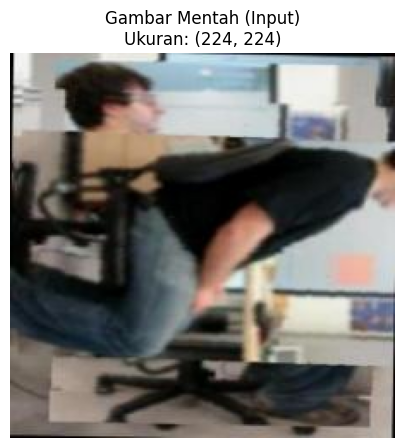

In [2]:
# Load gambar asli
img = Image.open(image_path).convert("RGB")

# Tampilkan visualnya
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Gambar Mentah (Input)\nUkuran: {img.size}")
plt.axis('off')
plt.show()

=== HASIL EKSTRAKSI TENSOR ===
Bentuk Tensor Asli (C, H, W): [3, 224, 224]
Total Nilai Pixels x Channels: 150,528
------------------------------


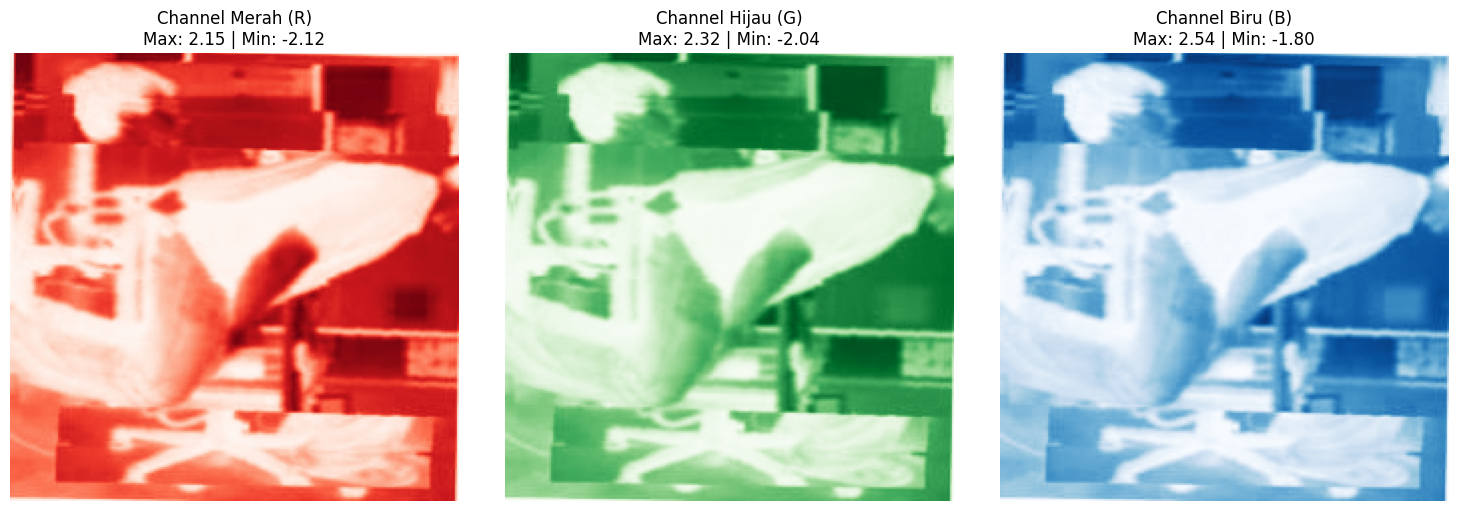

In [3]:
# Pipeline Preprocessing
preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Eksekusi pipeline
img_tensor = preprocess_pipeline(img)

print("=== HASIL EKSTRAKSI TENSOR ===")
print(f"Bentuk Tensor Asli (C, H, W): {list(img_tensor.shape)}")
print(f"Total Nilai Pixels x Channels: {img_tensor.numel():,}")
print("-" * 30)

# Visualisasi pemecahan 3 Channel (Merah, Hijau, Biru)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
channels = ['Merah (R)', 'Hijau (G)', 'Biru (B)']
cmaps = ['Reds', 'Greens', 'Blues']

for i in range(3):
    # Ekstraksi masing-masing channel dari tensor
    chan_data = img_tensor[i].numpy()
    axes[i].imshow(chan_data, cmap=cmaps[i])
    axes[i].set_title(f"Channel {channels[i]}\nMax: {chan_data.max():.2f} | Min: {chan_data.min():.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()